**------ 1. Importing Libraries ------**

In [3]:
import os                                                           #provides functions to interact with the OS like paths, files, directories)
import numpy as np                                                  #library for numerical computations,math operations and arrays
import pandas as pd                                                 #library used to handle datasets in tables called DataFrames
import matplotlib.pyplot as plt                                     #library for plotting graphs and visualizations
from sklearn.model_selection import train_test_split                #splits dataset into training and testing datasets
from sklearn.preprocessing import StandardScaler                    #scales/normalizes features so they are on similar ranges
from sklearn.metrics import mean_absolute_error, r2_score           #functions to evaluate model performance (MAE and R^2)
from sklearn.neural_network import MLPRegressor                     #a simple neural network model from scikit-learn
import joblib                                                       #used to save and load trained models to/from disk
from google.colab import files                                      #special tool for google colab to upload files from your computer
uploaded = files.upload()                                           #opens a file upload box so you can upload the dataset into colab

Saving student-mat.csv to student-mat.csv


**------ 2. Defining Paths ------**

In [4]:
DATA_PATH = "student-mat.csv"                                       #input dataset path(the students performance dataset)
MODEL_PATH = r"C:\Case Study\student\student_fcnn_model.joblib"     #output path for the trained model
PRED_OUT= r"C\Case Study\student\student_predictions.csv"           #output path for predictions

**------ 3.Loads Dataset ------**

In [10]:
df = pd.read_csv(DATA_PATH, sep=";")              #it loads dataset in pandas dataframe and telling pandas the columns are separated by semicolumns
print("Loaded(rows*columns) :", df.shape)         #prints the number of rows and columns
print("Columns:", df.columns.tolist())            #prints the column names in the dataset

Loaded(rows*columns) : (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [9]:
df.head()                                         #prints first 5 rows

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [11]:
df.tail()                                         #prints last 5 rows

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [12]:
df.describe()                                     #prints statistical summary of the dataset

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


------ 4. Pre-Process ------

In [15]:
target_col = "G3"                                                                #the final grade (G3) is your prediction target
#here we want to separate categorical(text) and numerical(number) values
cat_cols = df.select_dtypes(include=['object']).columns.tolist()                 #gives a new Dataframe containing only the categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()                #gives a new Dataframe containing only numerical columns
if target_col in num_cols:                                                       #check if target_column is there in num_cols
  num_cols.remove(target_col)                                                    #if it is there then remove it from num_cols
if target_col in cat_cols:                                                       #check if target_column is there in cat_cols
  cat_cols.remove(target_col)                                                    #if it is there then remove it from cat_cols
print("Target column:", target_col)                                              #print the target column
print("Categorical columns:", cat_cols)                                          #prints the categorical values
print("Numerical columns:", num_cols)                                            #prints numerical values

Target column: G3
Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


------ 5.#On-hot encode categorical features ------

In [22]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)      #it changes every categorical values into numbers that ML models can use
X = df_encoded.drop(columns=[target_col])                               #which gives all numeric columns and converted numeric values except target_col
y = df_encoded[target_col].values
print("X:", X)
print("y:", y)

X:      age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  \
0     18     4     4           2          2         0       4         3   
1     17     1     1           1          2         0       5         3   
2     15     1     1           1          2         3       4         3   
3     15     4     2           1          3         0       3         2   
4     16     3     3           1          2         0       4         3   
..   ...   ...   ...         ...        ...       ...     ...       ...   
390   20     2     2           1          2         2       5         5   
391   17     3     1           2          1         0       2         4   
392   21     1     1           1          1         3       5         5   
393   18     3     2           3          1         0       4         4   
394   19     1     1           1          1         0       3         2   

     goout  Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  \
0        4     1  ...  

------ 6.scale features ------

In [23]:
#scale features (safe to scale entire X since one-hot are 0/1)
scaler = StandardScaler()                                                #creates scaler
X = scaler.fit_transform(X)                                              #calculates mean&std to each coloumn of X and apply the formula (X-mean/std of each value)
print("Scaled X:", X)

Scaled X: [[ 1.02304645  1.14385567  1.36037064 ...  0.23094011 -2.23267743
  -0.70844982]
 [ 0.23837976 -1.60000865 -1.39997047 ...  0.23094011  0.44789274
  -0.70844982]
 [-1.33095364 -1.60000865 -1.39997047 ...  0.23094011  0.44789274
  -0.70844982]
 ...
 [ 3.37704655 -1.60000865 -1.39997047 ...  0.23094011 -2.23267743
  -0.70844982]
 [ 1.02304645  0.22923423 -0.47985677 ...  0.23094011  0.44789274
  -0.70844982]
 [ 1.80771315 -1.60000865 -1.39997047 ...  0.23094011  0.44789274
  -0.70844982]]


------ 7.#Train-test split ------

In [25]:
'''X_train=features for training
X_test=features for testing
y_train=target for training
y_test=target for testing'''

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)            #splits your dataset into training and testing sets so we can train the model on one part and test its accuracy in one model
print("Train/test shapes:", X_train.shape, X_test.shape)                                             # prints the size(R*C) of training and test data

Train/test shapes: (316, 41) (79, 41)


------8. Model (Sklearn MLP fallback) ------

In [30]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32),                 #2layers: first has 64 neurons, second has 32
                   activation='relu',                           #some math function used on neurons for the model understand non-linear relationships
                   solver='adam',                               #method used to learn like how a student studies
                   max_iter=1000,                               #max number of 1000 training
                   early_stopping=True,                         #stops training automatically if the model performance stops improving
                   n_iter_no_change=10,                         #number of iterations without improvement before stopping
                   tol=1e-4,                                    #if improvement is smaller than this threshold, model considers it as 'no change'
                   random_state=42,                             #fixes randomness so results are reproduciable
                   verbose=False)                               #doesn't print training progress
mlp.fit(X_train, y_train)                                 #trains the neural network on the training set
print("Training iterations:", mlp.n_iter_)

Training iterations: 289


--- 9. Evaluate ---

In [34]:
y_pred = mlp.predict(X_test)                               #makes predictions on the test set using the trained model
mae = mean_absolute_error(y_test, y_pred)                  #on avg, how many marks wrong?
mse = np.mean((y_test - y_pred)**2)                        #on avg, how much wrong?
r2 = r2_score(y_test, y_pred)                              #how good is the model compared to random guessing?
print("MAE:", mae)
print("MSE:", mse)
print("R^2:", r2)

MAE: 1.94045937579379
MSE: 6.782471454831355
R^2: 0.6692291724001931


------ 10. save outputs ------

In [40]:
#model
joblib.dump(mlp, MODEL_PATH)                                                              #this saves the trained neural network into a file
#predictions csv
pred_df = pd.DataFrame({'Actual_G3': y_test, 'Predicted_G3': np.round(y_pred, 2)})        #saves it  into csv file in PRED_OUT
pred_df.to_csv(PRED_OUT, index=False)
print("Saved model to:", MODEL_PATH)
print("Saved predictions to:", PRED_OUT)
files.download(MODEL_PATH)
files.download(PRED_OUT)

Saved model to: C:\Case Study\student\student_fcnn_model.joblib
Saved predictions to: C\Case Study\student\student_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
print(pred_df.head())                                             #first 5  Actual_G3 & Predicted_G3

   Actual_G3  Predicted_G3
0         10          7.83
1         12         11.39
2          5          2.66
3         10          9.82
4          9         12.22


------11. PLOTS ------

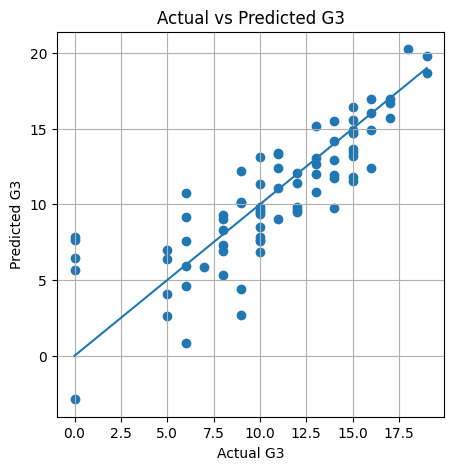

In [42]:
#Actual Vs Predicted scatter
plt.figure(figsize=(5, 5))                                                   #make 5x5 inch square plot
plt.scatter(y_test, y_pred)                                                  #plots the actual vs predicted values
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])         #draw a straight diagonal line
plt.xlabel('Actual G3')                                                      #label of x-axis
plt.ylabel('Predicted G3')                                                   #label of y-axis
plt.title('Actual vs Predicted G3')                                          #title of the graph
plt.grid(True)                                                               #shows background grid lines
plt.show()                                                                   #display the plot

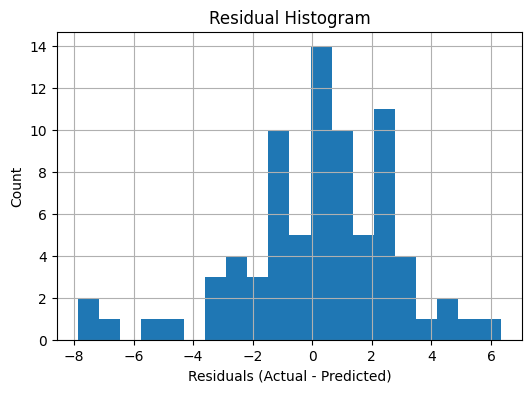

In [43]:
#Residual Histogram
residuals = y_test - y_pred                                #calculate errors (real - predicted)
plt.figure(figsize=(6, 4))                                 #make 6x inch plot
plt.hist(residuals, bins=20)                               #plot histogram of residuals
plt.xlabel('Residuals (Actual - Predicted)')               #x-axix label
plt.ylabel('Count')                                        #y-axis label
plt.title('Residual Histogram')                            #title
plt.grid(True)                                             #background grid
plt.show()                                                 #display the plot


In [ ]:
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
